# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo: la versión completa de `listings`, con 90 columnas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/raw/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,71615,...,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,90417,...,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,NaN,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,...,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,NaN,2,2,0,0,1.59
3,36763,https://www.airbnb.com/rooms/36763,20260624162917,2026-07-03,previous scrape,In front of the beach,NaN,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,158596,...,4.92,4.92,4.82,NaN,NaN,1,0,1,0,0.60
4,40983,https://www.airbnb.com/rooms/40983,20260624162917,2026-06-25,city scrape,Architect's Loft near Gaudí & Passeig de Gràcia,Stay in a charming architect-designed loft in ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,177617,...,4.86,4.91,4.52,Barcelona - Regional registration number<br />...,NaN,5,2,3,0,2.46


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
df.dtypes.value_counts()

(15293, 90)


float64    42
object     30
int64      18
Name: count, dtype: int64

90 columnas (15293 filas): 42 `float64`, 30 `object`, 18 `int64`. Ya llaman la atención dos cosas: `price` es `object` en vez de numérico (se ve en la sección 3), y hay columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...). Esto hace sospechar que son columnas vacías, así que se comprueba a continuación.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated             100.0
host_acceptance_rate         100.0
host_neighbourhood           100.0
host_response_rate           100.0
host_response_time           100.0
host_since                   100.0
host_thumbnail_url           100.0
host_total_listings_count    100.0
host_verifications           100.0
instant_bookable             100.0
neighborhood_overview        100.0
neighbourhood                100.0
dtype: float64

**12 columnas están completamente vacías** (100% nulas): `neighbourhood`, `host_acceptance_rate`, `host_response_time`, `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `host_since`, `host_response_rate`, `instant_bookable`, `neighborhood_overview`, `calendar_updated`. De las 90 columnas del dataset, solo 78 tienen algún dato real. Bastante de lo que promete el nombre de la columna (`host_since`, `host_response_rate`...) no está disponible en este dump concreto. No se eliminan aquí, se tratan formalmente en la sección 4 (Nulos), pero conviene tenerlo presente desde ya.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,15293.0,7.081310e+17,6.550632e+17,1.867400e+04,3.223180e+07,8.005535e+17,1.344730e+18,1.714532e+18
scrape_id,15293.0,2.026062e+13,0.000000e+00,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,15293.0,1.029976e+16,1.316853e+17,1.070400e+04,9.469830e+06,9.633738e+07,3.463675e+08,1.713762e+18
host_profile_id,15206.0,1.470058e+18,2.707029e+16,1.462507e+18,1.462659e+18,1.465487e+18,1.469532e+18,1.714078e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,15206.0,8.643628e+00,4.120495e+00,0.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01,1.700000e+01
hosts_time_as_user_months,15206.0,5.134618e+00,3.482615e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,15206.0,7.851309e+00,4.282838e+00,0.000000e+00,4.000000e+00,8.000000e+00,1.100000e+01,1.500000e+01
hosts_time_as_host_months,15206.0,4.990464e+00,3.549561e+00,0.000000e+00,1.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01


Un par de cosas más a tener en cuenta de cara a las siguientes secciones: `price` llega como texto (`"$409.00"`, no `409.00`), así que habrá que limpiarlo antes de poder tratarlo como numérico; y hay un grupo de columnas `price_quote_*` (`price_quote_total_price`, `price_quote_price_per_night`, `price_quote_raw`...) que no son estándar de Inside Airbnb: parecen una cotización para unas fechas concretas de check-in/check-out, no el precio base del anuncio. Se investigan con más detalle cuando lleguemos a `price` en la sección 7.

## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido.

#### `price`

Llega como texto con símbolo de moneda y separador de miles (`"$409.00"`). Se limpia y se convierte a `float`.

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

`last_scraped`, `first_review`, `last_review` y `calendar_last_scraped` son fechas guardadas como texto. `host_since` también debería ser una fecha, pero se deja fuera: es una de las 12 columnas 100% vacías detectadas en la sección 2, no tiene sentido convertir el tipo de una columna sin datos (se eliminará en la sección 4).

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` y `has_availability` son booleanos codificados como texto (`"t"`/`"f"`), con algún nulo suelto. Se mapean a `boolean` (el tipo nullable de pandas, admite `True`/`False`/`NA` a la vez, la misma idea que `Int64` para enteros con nulos).

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

Es un identificador entero, pero como tiene algunos nulos (87 filas) pandas lo infirió como `float64`. Se pasa a `Int64` (entero nullable).

In [9]:
df["host_profile_id"] = df["host_profile_id"].astype("Int64")
df["host_profile_id"].dtype

Int64Dtype()

Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` (texto) y el resto de columnas `price_quote_*`: su utilidad real (si se quedan o se descartan) se decide al analizar `price` a fondo en la sección 7, no aquí.

## 4. Nulos

Identificar qué columnas tienen valores nulos, en qué cantidad/proporción, y decidir cómo tratarlos (imputar, crear flag o descartar filas). Con 90 columnas es de esperar bastantes más nulos que en la versión resumida (p. ej. en las columnas de `review_scores_*` o `bathrooms`).

In [10]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

neighbourhood                  100.00
host_acceptance_rate           100.00
host_response_time             100.00
host_thumbnail_url             100.00
host_neighbourhood             100.00
host_total_listings_count      100.00
host_verifications             100.00
host_since                     100.00
host_response_rate             100.00
instant_bookable               100.00
neighborhood_overview          100.00
calendar_updated               100.00
host_about                      31.77
bathrooms                       23.31
review_scores_accuracy          23.21
review_scores_value             23.21
review_scores_checkin           23.21
review_scores_communication     23.21
review_scores_location          23.21
review_scores_cleanliness       23.21
review_scores_rating            23.20
last_review                     23.20
first_review                    23.20
reviews_per_month               23.20
host_location                   20.26
license                         19.90
bedrooms    

### 4.1 Estrategia

Cada grupo de columnas se trata según su causa, no con una regla única:
- 12 columnas 100% vacías (ya detectadas en la sección 2) → se eliminan.
- `bathrooms` → se recupera casi todo desde `bathrooms_text`, en vez de imputar o descartar.
- Reviews (`reviews_per_month`, `first_review`/`last_review`, `review_scores_*`) → sin reviews todavía.
- `license` → sin licencia registrada.
- `price` → variable clave, no se imputa.
- Columnas de host/calendario de bajo volumen → se descartan las filas.
- `bedrooms`/`beds` → se diagnostican pero se deja la decisión pendiente, no es un caso tan claro como los anteriores.
- Campos de texto (`host_about`, `host_location`, `description`) → se dejan tal cual, un nulo en texto libre no bloquea nada.

#### Columnas 100% vacías

Las 12 detectadas en la sección 2. Se eliminan: no aportan ninguna información.

In [11]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
]
df = df.drop(columns=empty_cols)
df.shape

(15293, 78)

#### `bathrooms`

`bathrooms` (numérico) tiene 3565 nulos, pero `bathrooms_text` (texto, p. ej. `"1.5 baths"`, `"Shared half-bath"`) solo tiene 13. Casi toda la información está ahí, solo que sin parsear a número. Se extrae el número de `bathrooms_text` (con `"half-bath"` → 0.5) y se usa para rellenar `bathrooms` en vez de imputar o descartar filas.

In [12]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False) & bathrooms_extracted.isnull()
bathrooms_extracted[half_mask] = 0.5

recovered = df["bathrooms"].isnull() & bathrooms_extracted.notnull()
print("bathrooms recuperados desde bathrooms_text:", recovered.sum())

df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
df["bathrooms"].isnull().sum()

bathrooms recuperados desde bathrooms_text: 3556


np.int64(9)

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

Se comprueba que el nulo coincide con `number_of_reviews == 0` (alojamiento sin reviews todavía).

In [13]:
mask = df["review_scores_rating"].isnull()
print("coincide con number_of_reviews == 0:", (df.loc[mask, "number_of_reviews"] == 0).all())
print("reviews_per_month coincide:", (df["reviews_per_month"].isnull() == mask).all())

coincide con number_of_reviews == 0: True
reviews_per_month coincide: True


Se confirma. `reviews_per_month` se imputa a 0 (valor real, no inventado). `first_review`/`last_review` se dejan como `NaT`, y los `review_scores_*` se dejan como `NaN`: no existe una puntuación real que darle a un alojamiento sin reviews, inventar una nota sería el peor tipo de dato falso posible aquí.

In [14]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

El nulo probablemente significa que no hay licencia registrada. Se guarda esa señal como flag antes de imputar el texto.

In [15]:
df["has_license"] = df["license"].notna()
df["license"] = df["license"].fillna("Sin licencia")

#### `price`

Variable clave (12.67% nulo, 1938 filas): no se imputa, se descartan esas filas.

In [16]:
df = df.dropna(subset=["price"])
df.shape

(13355, 79)

#### Columnas de bajo volumen (host, disponibilidad, estancia)

`host_profile_id`, `host_is_superhost`, `host_name`, `hosts_time_as_user_years/_months`, `host_identity_verified`, `host_has_profile_pic`, `hosts_time_as_host_years/_months`, `host_listings_count`, `host_picture_url`, `host_profile_url`, `has_availability`, `bathrooms_text` (los 13 que no se recuperaron) y la familia de `minimum_nights`/`maximum_nights`: entre todas afectan a muy pocas filas (1.16% del dataset), y son en su mayoría identificadores/metadatos de cuenta, así que no tiene sentido imputarlos. Se descartan las filas.

In [17]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(13258, 79)

#### `bedrooms` / `beds`

Tras lo anterior quedan `bedrooms` con 11.56% de nulos y `beds` con 5.23%. El nulo de `bedrooms` no es aleatorio: se concentra en `Private room` (41.2%) y `Shared room` (12.4%) frente a `Entire home/apt` (2.8%) y `Hotel room` (10.3%). Tiene sentido: si solo alquilas una habitación el host muchas veces no rellena "nº de dormitorios" del piso entero.

Se imputa con la **mediana de `bedrooms`/`beds` dentro de cada `room_type`**, en vez de una mediana global: la mediana de `bedrooms` ya sale exactamente 1 para `Private room`/`Shared room`/`Hotel room` y 2 para `Entire home/apt`, coincide con lo que vimos antes (88.5% de los `Private room` conocidos valen 1), así que no hace falta una regla especial aparte, el groupby ya lo captura solo.

In [18]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))

df[["bedrooms", "beds"]].isnull().sum()

bedrooms    0
beds        0
dtype: int64

In [19]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     30.19
review_scores_cleanliness      22.08
review_scores_value            22.08
review_scores_rating           22.08
review_scores_accuracy         22.08
review_scores_checkin          22.08
review_scores_communication    22.08
review_scores_location         22.08
first_review                   22.08
last_review                    22.08
host_location                  19.63
description                     3.49
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (informativamente vacíos, no se inventan) y los campos de texto libre `host_about`, `host_location`, `description`. Un nulo ahí no bloquea nada, no hace falta imputarlo para seguir con el EDA.

## 5. Duplicados

Comprobar si existen filas duplicadas en el dataset y eliminarlas si procede.

In [20]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [21]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

Filas que comparten `name`, `host_name`, `latitude` y `longitude` pero tienen `id` distinto: es de esperar que sea el mismo alojamiento publicado varias veces.

In [22]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
logical_dup_mask = df.duplicated(subset=dup_cols, keep=False)

print("filas implicadas:", logical_dup_mask.sum())
print("grupos:", df[logical_dup_mask].groupby(dup_cols).ngroups)

filas implicadas: 221
grupos: 83


Con 79 columnas es muy difícil que dos filas coincidan en absolutamente todo por azar (fechas de review, puntuaciones, disponibilidad...). Se comprueba si sigue habiendo alguna.

In [23]:
cols_except_id = [c for c in df.columns if c != "id"]
is_real_duplicate = df.duplicated(subset=cols_except_id, keep="first")
is_real_duplicate.sum()

np.int64(0)

#### Conclusión

0 filas duplicadas de fila completa, 0 `id` repetidos, y 0 filas idénticas en todo salvo `id`: **no hay ningún duplicado que eliminar**. Los 221 "duplicados lógicos" (mismo edificio/host) que sí aparecen son anuncios reales distintos, con datos propios en el resto de columnas (reviews, disponibilidad, licencia...). No se toca nada.

## 6. Variables Categóricas

Análisis univariante de las variables categóricas: cardinalidad y distribución de frecuencias de cada una.

In [24]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                     13258
picture_url                     13125
name                            12753
price_quote_raw                 11948
amenities                       11337
description                     10178
license                          9775
host_url                         3495
host_profile_url                 3495
host_picture_url                 3421
host_name                        2045
host_about                       1895
price_quote_checkout_date         331
price_quote_checkin_date          291
host_location                     221
neighbourhood_cleansed             69
property_type                      47
bathrooms_text                     37
neighbourhood_group_cleansed       10
room_type                           4
host_identity_verified              2
source                              2
host_has_profile_pic                2
host_is_superhost                   2
has_license                         2
has_availability                    1
dtype: int64

### 6.1 Cardinalidad: cuatro grupos, no dos

Con 79 columnas hace falta algo más que la simple distinción entre "identificador" y "categórica":

- **URLs, cardinalidad prácticamente igual al nº de filas** (`listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`): cero valor analítico, ni siquiera como texto libre. No se tratan como categóricas.
- **Cuasi-identificadores de texto libre** (`name`, `description`, `host_about`, `amenities`, `host_name`, `host_location`, `license`): se difiere cualquier señal de texto a feature engineering.
- **Pendientes de la sección 7** (`price_quote_checkin_date`, `price_quote_checkout_date`, `price_quote_raw`): su destino depende de qué se decida sobre `price_quote_*` en general.
- **`bathrooms_text`**: ya cumplió su función en la sección 4, de ahí se sacó `bathrooms` numérico. No aporta nada que no esté ya en `bathrooms`, no se analiza aparte.
- **Categóricas reales de baja cardinalidad**, las únicas que se analizan a continuación: `source` (2), `property_type` (47), `room_type` (4), `neighbourhood_cleansed` (69), `neighbourhood_group_cleansed` (10), `has_availability` (1), y los booleanos `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `has_license`.

### 6.2 Categóricas de baja cardinalidad

#### `has_availability`

Antes de nada: tras los descartes de filas en la sección 4, esta columna se quedó con un único valor.

In [25]:
df["has_availability"].value_counts(dropna=False)

has_availability
True    13258
Name: count, dtype: Int64

`True` en las 13258 filas: es una constante, no distingue nada. Ya no aporta información (por eso encajaba con `availability_365` alto en general), así que se elimina.

In [26]:
df = df.drop(columns=["has_availability"])

#### `source`

In [27]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        96.2
previous scrape     3.8
Name: proportion, dtype: float64

96.2% `city scrape` / 3.8% `previous scrape`. Es un metadato de cómo se recolectó el anuncio, no del alojamiento en sí, así que tiene poco margen para aportar señal a `price`. Se deja como está.

#### `property_type`

Más granular que `room_type` (47 categorías vs. 4).

In [28]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   9122
Private room in rental unit          2101
Entire serviced apartment             341
Entire condo                          286
Room in hotel                         260
Private room in hostel                196
Entire loft                           172
Private room in home                  124
Room in boutique hotel                113
Entire home                            89
Private room in condo                  80
Shared room in hostel                  64
Private room in bed and breakfast      63
Entire townhouse                       20
Entire vacation home                   18
Name: count, dtype: int64

Dominado por `Entire rental unit` (69%) y `Private room in rental unit` (16%); el resto son categorías con poca muestra cada una (hoteles, hostales, lofts...). Con esta cola larga de categorías raras, si se usa como feature habrá que agruparlas, pero eso se decide en feature engineering, no aquí.

#### `room_type`

In [29]:
df["room_type"].value_counts()

room_type
Entire home/apt    10107
Private room        2996
Shared room           97
Hotel room            58
Name: count, dtype: int64

`Entire home/apt` domina, `Shared room`/`Hotel room` son casi residuales.

#### `neighbourhood_group_cleansed` / `neighbourhood_cleansed`

In [30]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Eixample               5170
Ciutat Vella           2757
Sants-Montjuïc         1276
Sant Martí             1224
Gràcia                 1191
Sarrià-Sant Gervasi     767
Horta-Guinardó          290
Les Corts               262
Sant Andreu             180
Nou Barris              141
Name: count, dtype: int64

`Eixample` y `Ciutat Vella` concentran la mayoría de anuncios. No se repite aquí el análisis detallado de barrios raros y su agrupación en "Otros"; se retomará si hace falta al preparar los datos para modelar.

#### Columnas booleanas

In [31]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c)
    print(df[c].value_counts(normalize=True).mul(100).round(1))
    print()

host_is_superhost
host_is_superhost
False    72.2
True     27.8
Name: proportion, dtype: Float64

host_has_profile_pic
host_has_profile_pic
True     97.8
False     2.2
Name: proportion, dtype: Float64

host_identity_verified
host_identity_verified
True     96.5
False     3.5
Name: proportion, dtype: Float64

has_license
has_license
True     86.6
False    13.4
Name: proportion, dtype: float64



`host_has_profile_pic` (97.8%) y `host_identity_verified` (96.5%) están casi siempre a `True`, con poca variabilidad, así que aportarán poco como predictoras. `host_is_superhost` (27.8% `True`) tiene más equilibrio, con potencial real de señal. `has_license` está a `True` en el 86.5% de los casos.

## 7. Numéricas

Análisis univariante de las variables numéricas: estadísticos descriptivos y forma de la distribución. Aquí es donde entran `accommodates`, `bedrooms`, `beds`, `bathrooms` y los `review_scores_*`.

In [32]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols.tolist())
len(num_cols)

['id', 'scrape_id', 'host_id', 'host_profile_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_h

49

### 7.1 Identificadores/geográficas vs. variables de interés

49 columnas numéricas: demasiadas para analizar todas igual. `id`, `scrape_id`, `host_id`, `host_profile_id` son identificadores; `latitude`/`longitude` se tratan en la sección 11. El resto (45 columnas) sí son variables de interés, pero muchas están agrupadas en "familias" muy redundantes entre sí, se revisan antes de elegir cuáles analizar a fondo.

### 7.2 Familias de variables redundantes

Hay grupos de variables casi repetidas entre sí:
- **Estancia**: `minimum_nights`, `maximum_nights`, `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm` (8 columnas).
- **Disponibilidad**: `availability_30`, `availability_60`, `availability_90`, `availability_365`, `availability_eoy` (5 columnas).
- **Reviews recientes**: `number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_l30d`, `number_of_reviews_ly` (4 columnas, distintas ventanas temporales).

Se comprueba cuánto se solapan antes de decidir cuáles usar.

In [33]:
nights_family = [
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]
df[nights_family].corr().round(2)

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm
minimum_nights,1.00,-0.17,1.00,0.40,-0.04,-0.17,0.49,-0.11
maximum_nights,-0.17,1.00,-0.17,-0.00,0.79,1.00,-0.02,0.92
minimum_minimum_nights,1.00,-0.17,1.00,0.40,-0.04,-0.17,0.49,-0.11
maximum_minimum_nights,0.40,-0.00,0.40,1.00,0.02,-0.00,0.95,0.02
minimum_maximum_nights,-0.04,0.79,-0.04,0.02,1.00,0.79,0.01,0.93
maximum_maximum_nights,-0.17,1.00,-0.17,-0.00,0.79,1.00,-0.02,0.92
minimum_nights_avg_ntm,0.49,-0.02,0.49,0.95,0.01,-0.02,1.00,0.01
maximum_nights_avg_ntm,-0.11,0.92,-0.11,0.02,0.93,0.92,0.01,1.00


`minimum_nights` y `minimum_minimum_nights` correlacionan **1.00**: son literalmente el mismo dato. `maximum_nights` correlaciona 0.92-0.93 con `maximum_maximum_nights`/`minimum_maximum_nights`. No hace falta quedarse con las 8: para el EDA basta con `minimum_nights`/`maximum_nights`; el resto se deja para feature engineering solo si algún día aportan algo que las dos base no capturan.

In [34]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy"]
df[avail_family].corr().round(2)

,availability_30,availability_60,availability_90,availability_365,availability_eoy
availability_30,1.00,0.90,0.82,0.34,0.57
availability_60,0.90,1.00,0.95,0.38,0.68
availability_90,0.82,0.95,1.00,0.45,0.80
availability_365,0.34,0.38,0.45,1.00,0.73
availability_eoy,0.57,0.68,0.80,0.73,1.00


Aquí el solape es más moderado (0.34 a 0.90, más bajo cuanto más se alejan las ventanas): no son la misma variable repetida, cada una mira un horizonte distinto. Aun así, para el EDA se sigue usando `availability_365`, que es la más completa; las demás se dejan de lado por ahora, no se eliminan.

### 7.3 Comprobación: `hosts_time_as_*` y `host_listings_count`

En la sección 2 llamó la atención que `hosts_time_as_user_years/_months` y `hosts_time_as_host_years/_months` tuvieran datos pese a que `host_since` (de donde deberían derivarse) está 100% vacía. Se comprueba que de verdad tienen valores usables.

In [35]:
hosts_time_cols = ["hosts_time_as_user_years", "hosts_time_as_user_months", "hosts_time_as_host_years", "hosts_time_as_host_months"]
df[hosts_time_cols].describe()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months
count,13258.000000,13258.000000,13258.000000,13258.000000
mean,8.613290,5.096621,7.872153,4.943732
std,4.206002,3.466488,4.390327,3.514236
min,0.000000,0.000000,0.000000,0.000000
25%,6.000000,2.000000,4.000000,1.000000
50%,9.000000,5.000000,8.000000,5.000000
75%,12.000000,8.000000,12.000000,8.000000
max,17.000000,11.000000,15.000000,11.000000


Tienen valores completos y coherentes (0 nulos, rangos razonables en años/meses): son campos ya derivados que sobrevivieron aunque se vaciara `host_since`. Se pueden usar con normalidad como antigüedad del host.

In [36]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.00000,0.94492
calculated_host_listings_count,0.94492,1.00000


Correlación 0.94 entre `host_listings_count` (autodeclarado por el host) y `calculated_host_listings_count` (recalculado a partir del propio dataset). Miden lo mismo, pero `host_listings_count` es sistemáticamente más alto (media 114 vs. 81): probablemente incluye anuncios del host en otras ciudades, fuera de este dataset. Para el análisis de Barcelona interesa más `calculated_host_listings_count`.

### 7.4 Variables clave: estadísticos y asimetría

Con las familias resueltas, este es el conjunto de variables numéricas que sí se analiza a fondo: las variables básicas del alojamiento, más las nuevas de tamaño y calidad que trae la versión completa (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) y `estimated_revenue_l365d`.

In [37]:
num_vars = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "calculated_host_listings_count", "estimated_revenue_l365d",
]
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
price,13258.0,240.737357,340.541238,3.5,89.065,177.325,285.8675,10542.22
accommodates,13258.0,3.859934,2.513311,1.0,2.000,4.000,5.0000,16.00
bathrooms,13258.0,1.427365,0.985087,0.0,1.000,1.000,2.0000,16.00
bedrooms,13258.0,2.042767,1.464749,0.0,1.000,2.000,3.0000,29.00
beds,13258.0,2.807890,2.573410,1.0,1.000,2.000,4.0000,127.00
minimum_nights,13258.0,13.561171,15.742120,1.0,1.000,2.000,31.0000,250.00
maximum_nights,13258.0,572.482878,412.937569,2.0,330.000,365.000,1125.0000,1125.00
availability_365,13258.0,237.337607,100.048521,1.0,159.000,261.000,325.0000,365.00
number_of_reviews,13258.0,73.155981,138.301733,0.0,1.000,11.000,88.0000,2740.00
number_of_reviews_ltm,13258.0,14.654020,30.433867,0.0,0.000,3.000,23.0000,1276.00


In [38]:
df[num_vars].skew().sort_values(ascending=False)

number_of_reviews_ltm             14.973408
reviews_per_month                 13.693025
beds                              11.569499
price                              9.017005
bedrooms                           4.583359
number_of_reviews                  4.083094
bathrooms                          3.997626
estimated_revenue_l365d            2.318843
calculated_host_listings_count     2.211188
accommodates                       1.992078
minimum_nights                     1.613227
maximum_nights                     0.340334
availability_365                  -0.506738
review_scores_rating              -3.736466
dtype: float64

Varias variables tienen colas largas (`number_of_reviews_ltm`, `reviews_per_month`, `price` muy asimétricas), más dos cosas nuevas: `beds` tiene una asimetría enorme (11.6, `max=127`, probablemente hostales o albergues metidos como un único anuncio, a revisar en la sección 8) y `review_scores_rating` es la única con **asimetría negativa fuerte** (-3.74). La mayoría de anuncios puntúa muy alto, cerca de 5, y son los pocos malos los que estiran la cola hacia abajo, no al revés.

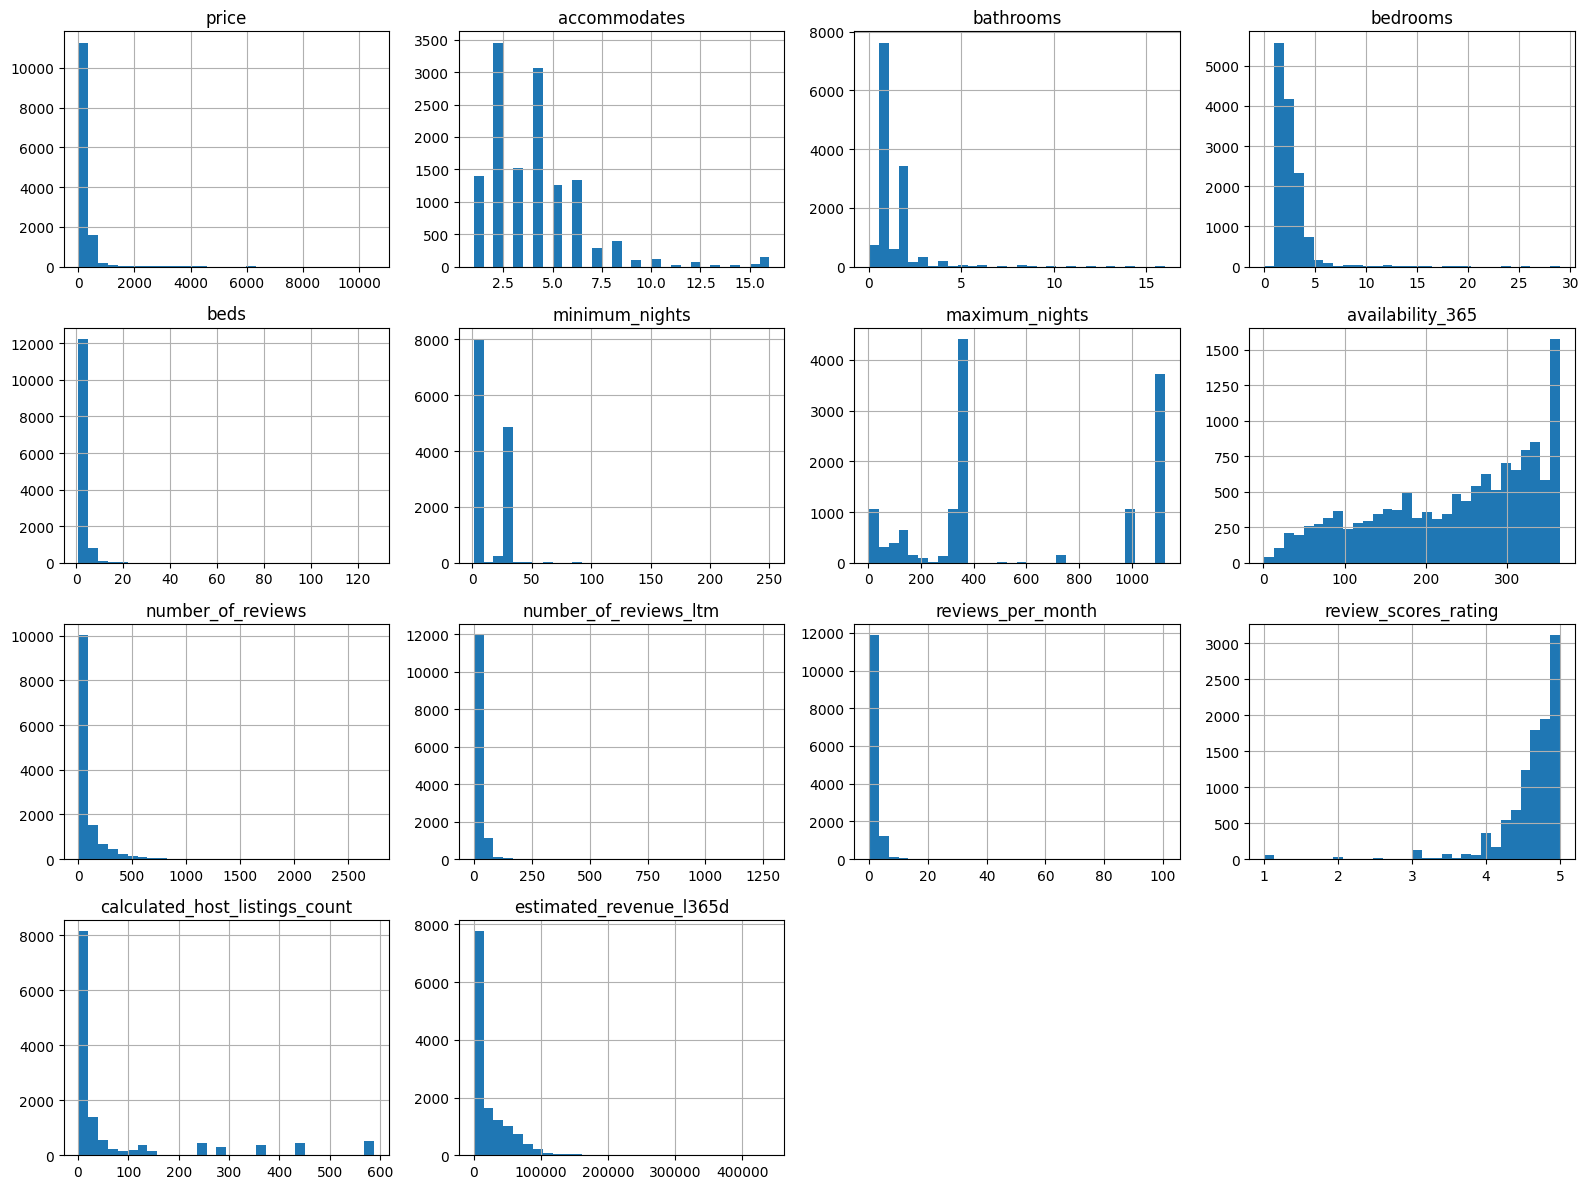

In [39]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis.

### 8.1 Método: rango intercuartílico (IQR)

Un valor se considera outlier si cae por debajo de `Q1 - 1.5·IQR` o por encima de `Q3 + 1.5·IQR`, aplicado a cada variable de `num_vars`.

In [40]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
12,calculated_host_listings_count,-69.00000,123.00000,2477,18.68
8,number_of_reviews,-129.50000,218.50000,1406,10.60
0,price,-206.13875,581.07125,585,4.41
9,number_of_reviews_ltm,-34.50000,57.50000,528,3.98
11,review_scores_rating,3.88500,5.52500,479,3.61
13,estimated_revenue_l365d,-53127.00000,88545.00000,467,3.52
1,accommodates,-2.50000,9.50000,431,3.25
10,reviews_per_month,-2.95000,5.05000,418,3.15
2,bathrooms,-0.50000,3.50000,380,2.87
4,beds,-3.50000,8.50000,278,2.10


`calculated_host_listings_count` (18.7%) y `number_of_reviews` (10.6%) encabezan la lista. Son colas largas reales, no errores. Lo nuevo es `review_scores_rating` (3.6%): al estar la mayoría de puntuaciones muy cerca de 5, el IQR marca como "outlier" cualquier nota algo más baja. No es un error, es la otra cara de la asimetría negativa que ya vimos en la sección 7.

### 8.2 Caso concreto: `bedrooms`/`beds` extremos

En la sección 7 quedó pendiente investigar `beds` (máximo 127) y `bedrooms` (máximo 29). No basta con el % del IQR, hay que mirar las filas en concreto.

In [41]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "price"]
df[df["beds"] > 30][cols].sort_values("beds", ascending=False)

,name,room_type,accommodates,bedrooms,beds,price
10049,Tunupa - 2 bedrooms and terrace in Sant Gervasi,Entire home/apt,4,2.0,127.0,146.07
11151,Great and nice 24-Bedrooms 12-Bathrooms Group ...,Entire home/apt,16,24.0,37.0,2739.00
12276,Prime Location: Nice 26-Bedrooms Group Flat 49ppl,Entire home/apt,16,26.0,35.0,3196.00
12195,Fab 20-Bedrooms Group Flat in Eixample: 40 Peo...,Entire home/apt,16,20.0,33.0,2283.00
12274,Nice 20-bedroom Group Flat in Lively Eixample 36p,Entire home/apt,16,20.0,33.0,3698.00
10504,Great 20-Bedr 10-Bathr Group Flat Eixample 40 ...,Entire home/apt,16,20.0,32.0,2283.00
11035,Great 24-Bedrooms 12-Bath Group Flat Nice Area...,Entire home/apt,16,24.0,31.0,2739.00


"Great 20-Bedr... Eixample", "Fab 20-Bedrooms Group Flat in Eixample": casi todas son "Group Flats" reales, con 16-26 dormitorios, capacidad para 16 personas (el máximo de `accommodates` en Airbnb), precios de 1800-3700€/noche. Son pisos para grupos grandes en el Eixample, consistentes entre sí: muchos dormitorios, mucha capacidad y precio alto. Son extremos genuinos, no errores.

Hay una excepción clara: *"Tunupa - 2 bedrooms and terrace in Sant Gervasi"* tiene `beds=127` pero solo 2 `bedrooms`, `accommodates=4` y `price=146€`, inconsistente con todo lo demás de esa misma fila (un piso de 4 personas no tiene 127 camas). Este sí es un error de captura, no una variabilidad real.

Se corrige igual que un nulo: se descarta el valor erróneo y se reimputa con la misma regla ya usada en la sección 4 (mediana de `beds` por `room_type`), en vez de dejarlo o inventar un número distinto sobre la marcha.

In [42]:
error_mask = (df["beds"] > 30) & (df["bedrooms"] < 5)
df.loc[error_mask, ["name", "bedrooms", "beds", "accommodates"]]

,name,bedrooms,beds,accommodates
10049,Tunupa - 2 bedrooms and terrace in Sant Gervasi,2.0,127.0,4


In [43]:
df.loc[error_mask, "beds"] = df.groupby("room_type")["beds"].transform("median")[error_mask]
df.loc[error_mask, ["name", "bedrooms", "beds", "accommodates"]]

,name,bedrooms,beds,accommodates
10049,Tunupa - 2 bedrooms and terrace in Sant Gervasi,2.0,3.0,4


### 8.3 Visualización

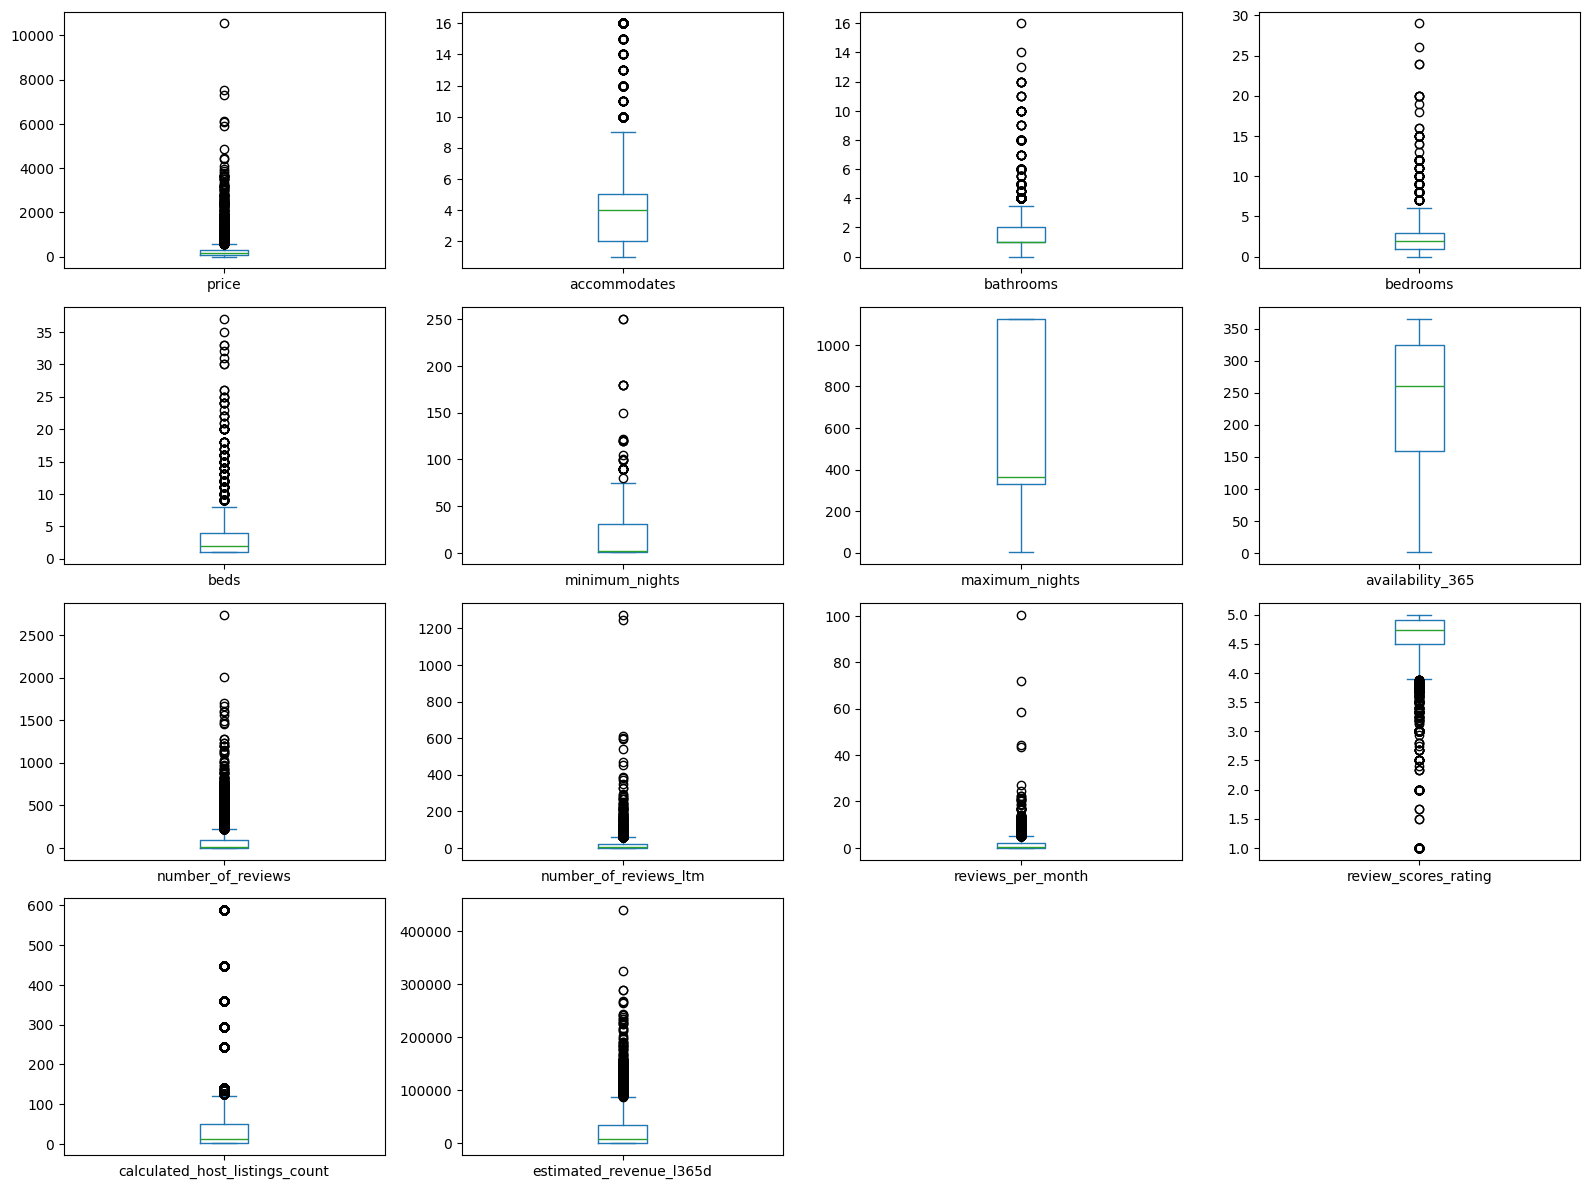

In [44]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.4 Conclusión y tratamiento

Con la única excepción ya corregida (la fila con `beds=127` mal capturada), **no se recorta nada más por IQR**: los "outliers" restantes (`calculated_host_listings_count`, `number_of_reviews`, `price`, los Group Flats de `bedrooms`/`beds`, y las notas bajas de `review_scores_rating`) son variabilidad real del mercado, no errores. Las transformaciones para modelar (logs, etc.) se dejarán para feature engineering.

## 9. Agrupaciones

Análisis bivariante: relación de `price` con otras variables categóricas.

`neighbourhood_group`/`room_type` se repasan brevemente, y el resto de la sección se dedica a lo que solo existe en esta versión completa: tamaño (`accommodates`/`bedrooms`/`bathrooms`/`beds`), calidad (`review_scores_rating`), y `has_license`/`host_is_superhost`.

#### `neighbourhood_group_cleansed` / `room_type` (repaso rápido)

In [45]:
print(df.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))
print()
print(df.groupby("room_type")["price"].agg(["count", "mean", "median"]))

                              count        mean   median
neighbourhood_group_cleansed                            
Eixample                       5170  309.572836  229.000
Sant Martí                     1224  224.050858  207.310
Sants-Montjuïc                 1276  219.618182  186.805
Gràcia                         1191  197.799446  187.730
Les Corts                       262  197.647863  162.385
Ciutat Vella                   2757  190.951911  114.120
Sarrià-Sant Gervasi             767  175.110652  148.360
Horta-Guinardó                  290  168.268724  118.485
Sant Andreu                     180  126.600611   79.690
Nou Barris                      141  120.709645   95.690

                 count        mean  median
room_type                                 
Entire home/apt  10107  284.802491  221.50
Hotel room          58  247.227241  195.00
Private room      2996   97.357340   61.94
Shared room         97   73.972474   46.00


`Eixample` es el más caro por media. `Ciutat Vella` baja mucho por mediana (114€), efecto de los pisos de lujo del centro histórico que inflan la media. `Entire home/apt` está muy por encima de `Private room`/`Shared room`.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

Estas son las variables de tamaño del alojamiento que solo trae la versión completa del dataset. Se mira primero la correlación con `price`.

In [46]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
for c in size_vars:
    print(f"{c}: pearson={df['price'].corr(df[c]):.2f}  spearman={df['price'].corr(df[c], method='spearman'):.2f}")

accommodates: pearson=0.65  spearman=0.69
bedrooms: pearson=0.66  spearman=0.55
bathrooms: pearson=0.59  spearman=0.28
beds: pearson=0.62  spearman=0.61


**Esto es un salto grande.** `bedrooms` sola llega a **0.66**, `accommodates` a 0.65, `beds` a 0.62 y `bathrooms` a 0.59: son, con diferencia, las variables más relacionadas con el precio de todo el proyecto hasta ahora. Confirma que merecía la pena trabajar con `listings.csv.gz`, la versión completa del dataset.

In [47]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
0.0,1,42.26
1.0,5579,97.80
2.0,4169,210.50
3.0,2338,279.00
4.0,740,346.50
5.0,159,509.00
6.0,96,1009.00
7.0,20,601.75
8.0,47,1284.00


Relación clara y casi monótona: 1 dormitorio → mediana 98€, 2 → 210€, 3 → 279€... hasta 9 dormitorios → 1806€ (los "Group Flats" de la sección 8). Alguna caída puntual (7 dormitorios por debajo de 6) es ruido de muestra pequeña (20-96 filas), no una tendencia real.

<Axes: xlabel='bedrooms', ylabel='price'>

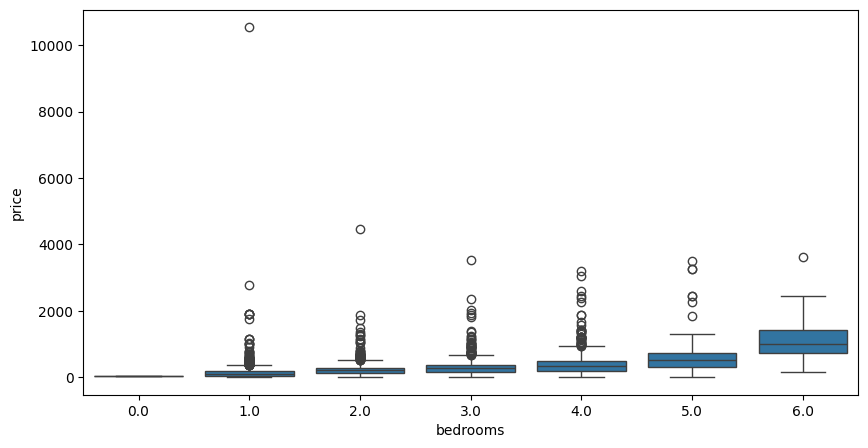

In [48]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")

Se limita a ≤6 dormitorios para que la caja no se aplaste por los Group Flats. Así la tendencia creciente se ve con claridad.

### 9.2 Calidad: `review_scores_rating`

La intuición dice que mejor puntuación debería permitir cobrar más. Se comprueba.

In [49]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(0.07669992676637652), np.float64(-0.02723740507984216))

**Prácticamente cero** (Pearson 0.08, Spearman -0.03): la puntuación de reviews no explica el precio. Tiene sentido si se piensa bien: casi todo el mundo puntúa alto (asimetría negativa ya vista en la sección 7), así que la nota apenas distingue entre anuncios. El precio se explica por tamaño y ubicación, no por lo bien valorado que esté.

### 9.3 `has_license`

En la sección 6 solo se vio la proporción (86.6% con licencia). Aquí se cruza con `price`.

In [50]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,1779,107.011315,73.03
True,11479,261.462039,203.00


Diferencia grande: mediana 203€ con licencia vs. 73€ sin ella, 2.8 veces más. Antes de leerlo como "la licencia sube el precio", se comprueba si es solo un efecto de `room_type` (las habitaciones privadas licencian menos que los pisos enteros).

In [51]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False          103.430
                 True           233.630
Hotel room       True           195.000
Private room     False           39.590
                 True            82.740
Shared room      False           50.315
                 True            46.000
Name: price, dtype: float64

La diferencia se mantiene **dentro de cada `room_type`** (p. ej. `Entire home/apt`: 234€ con licencia vs. 103€ sin ella), así que no es solo un efecto de `room_type`. Puede reflejar que los anuncios sin licencia son operaciones más pequeñas o informales que compiten con precios más bajos. Se deja como hallazgo para feature engineering, no se investiga la causa aquí.

### 9.4 `host_is_superhost`

In [52]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,9567,239.844228,161.0
True,3691,243.052330,220.0


Diferencia mucho más modesta (mediana 220€ vs. 161€) que en el caso de `has_license`. Ser Superhost pesa, pero bastante menos que tener licencia o el tamaño del alojamiento.

### 9.5 `property_type` (más granular que `room_type`)

In [53]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
property_type,,,
Entire serviced apartment,341,310.326188,282.330
Entire rental unit,9122,286.633215,221.000
Entire condo,286,239.119021,216.500
Entire home,89,281.411798,210.880
Room in boutique hotel,113,229.675487,198.000
Room in hotel,260,247.992231,175.475
Private room in hostel,196,200.150408,169.500
Entire loft,172,173.223605,151.430
Private room in home,124,78.667500,59.190


`Entire serviced apartment` es el tipo más caro (mediana 282€), por encima incluso de `Entire rental unit` (221€). Tiene sentido, suele incluir servicios extra como limpieza o recepción. `Private room in rental unit` es el más barato (47€). Aporta más matiz que `room_type`, pero con 47 categorías en total habrá que agrupar las menos frecuentes si se usa para modelar.

En conjunto, esta sección deja el hallazgo más importante de este EDA: **el tamaño (`bedrooms`/`accommodates`/`beds`/`bathrooms`) y `has_license` son los que más se relacionan con `price`**. `review_scores_rating` sorprende por no aportar casi nada. Se retoma todo esto de forma cuantitativa en la sección 10 (Correlación).

## 10. Correlación y visualización

Análisis multivariante: correlaciones entre variables numéricas y su relación conjunta con `price`.

### 10.1 Correlación con `price`

`corr_vars` combina `num_vars` con los flags booleanos (`has_license`, `host_is_superhost`). Se excluyen identificadores y `latitude`/`longitude`, que se tratan en la sección 11.

In [54]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
bedrooms                          0.658512
accommodates                      0.645524
beds                              0.617350
bathrooms                         0.590300
calculated_host_listings_count    0.214922
estimated_revenue_l365d           0.204010
has_license                       0.154596
availability_365                  0.096464
review_scores_rating              0.076700
number_of_reviews                 0.052066
number_of_reviews_ltm             0.042197
reviews_per_month                 0.029311
maximum_nights                    0.015242
host_is_superhost                 0.004223
minimum_nights                   -0.329257
Name: price, dtype: float64

Confirma lo visto en la sección 9: `bedrooms` (0.66), `accommodates` (0.65), `beds` (0.62) y `bathrooms` (0.59) son, con diferencia, lo más correlacionado con `price`, muy por delante de `calculated_host_listings_count` (0.21).

La correlación de Pearson asume una relación lineal, pero varias variables (reviews, `minimum_nights`) tienen colas largas, así que se compara también con Spearman.

In [55]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.689103
beds                              0.611151
bedrooms                          0.549048
estimated_revenue_l365d           0.489802
number_of_reviews                 0.430296
number_of_reviews_ltm             0.428999
reviews_per_month                 0.402154
has_license                       0.353487
bathrooms                         0.280900
host_is_superhost                 0.132877
maximum_nights                    0.117253
calculated_host_listings_count    0.105576
availability_365                  0.025371
review_scores_rating             -0.027237
minimum_nights                   -0.649278
Name: price, dtype: float64

Las variables de tamaño se mantienen arriba con **ambos** métodos, a diferencia de las de reviews, que solo destacan con Spearman: es una señal mucho más robusta. También cambia bastante entre métodos: `number_of_reviews` pasa de 0.05 a 0.43, `minimum_nights` de -0.33 a -0.65, `has_license` de 0.15 a 0.35.

Dato curioso: `host_is_superhost` es prácticamente 0 en ambos métodos (0.004 / 0.13), pese a que en la sección 9 la mediana de precio parecía distinta entre superhosts y no superhosts (220€ vs. 161€). La correlación mira toda la distribución, no solo dos medianas, y deja claro que el efecto real es débil: la comparación de grupos por sí sola exageraba la diferencia.

### 10.2 Heatmap

<Axes: >

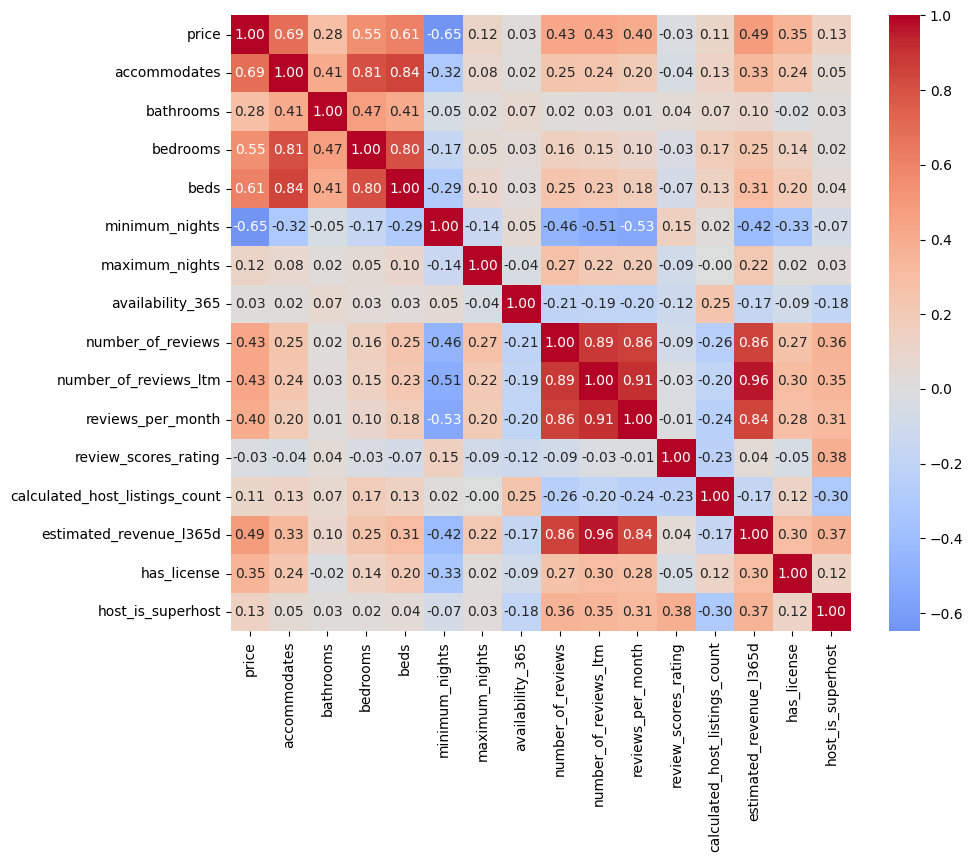

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_vars].corr(method="spearman"),
    annot=True, fmt=".2f", center=0, cmap="coolwarm",
)

Además de lo ya comentado, se ve que `accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí, algo esperable porque miden aspectos del mismo "tamaño". De cara a un modelo lineal habrá que vigilar la multicolinealidad entre ellas.

### 10.3 Pairplot

`price` (en `log1p`, por el sesgo) junto con `bedrooms` y `accommodates`. Estas dos no hace falta transformarlas: su rango es mucho más pequeño y no están tan sesgadas.

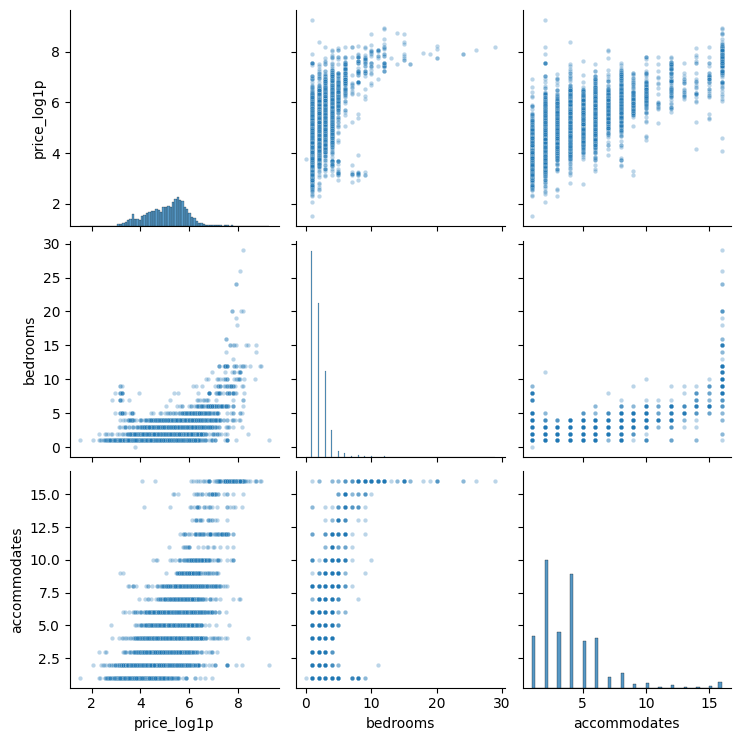

In [57]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price"] = np.log1p(pairplot_data["price"])
pairplot_data = pairplot_data.rename(columns={"price": "price_log1p"})

sns.pairplot(pairplot_data, plot_kws={"alpha": 0.3, "s": 10})

Se ve con claridad la relación creciente entre `price_log1p` y ambas variables, la línea vertical en `accommodates=16` (el máximo permitido en Airbnb) y, en la esquina superior derecha, el grupo aislado de los "Group Flats" de la sección 8: mucho `bedrooms`, mucho `accommodates`, precio alto. Son consistentes, no ruido.

La sección 10 deja claro el orden de importancia para un futuro modelo de `price`: primero el **tamaño** (`bedrooms`/`accommodates`/`beds`/`bathrooms`), después señales más suaves como `has_license` o el conjunto de variables de reviews (con Spearman), y al final cosas que apenas aportan por sí solas como `review_scores_rating` o `host_is_superhost`.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para detectar patrones de precio o densidad por zona.

### 11.1 Rango de coordenadas

In [58]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,41.351783,2.092414
max,41.462243,2.221390


El rango es coherente con Barcelona (lat ~41.35-41.46, long ~2.09-2.22): sin sorpresas.

### 11.2 Distribución espacial por distrito

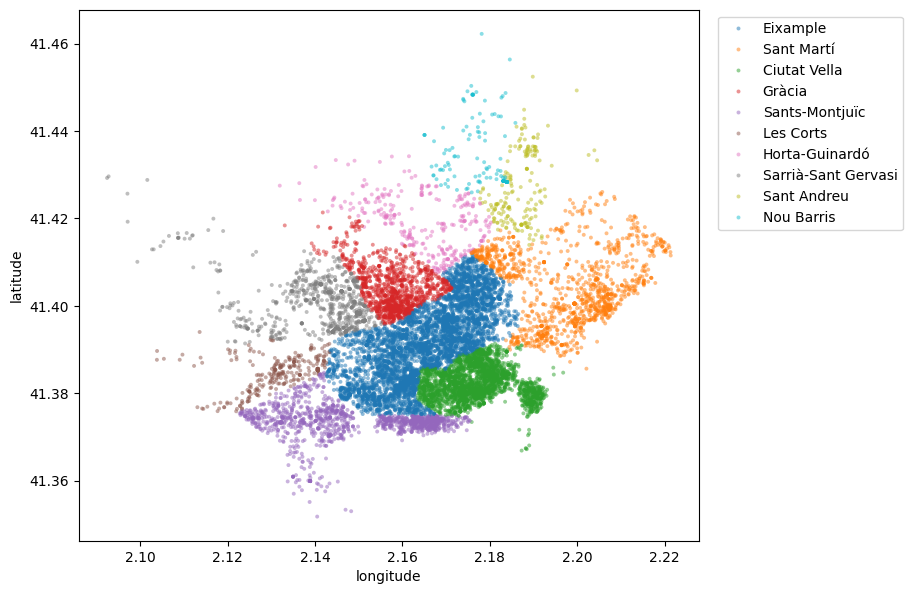

In [59]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_group_cleansed",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los distritos forman regiones geográficas compactas y reconocibles, lo que confirma que `neighbourhood_group_cleansed` está bien asignado.

### 11.3 Precio en el mapa

Text(0, 0.5, 'latitude')

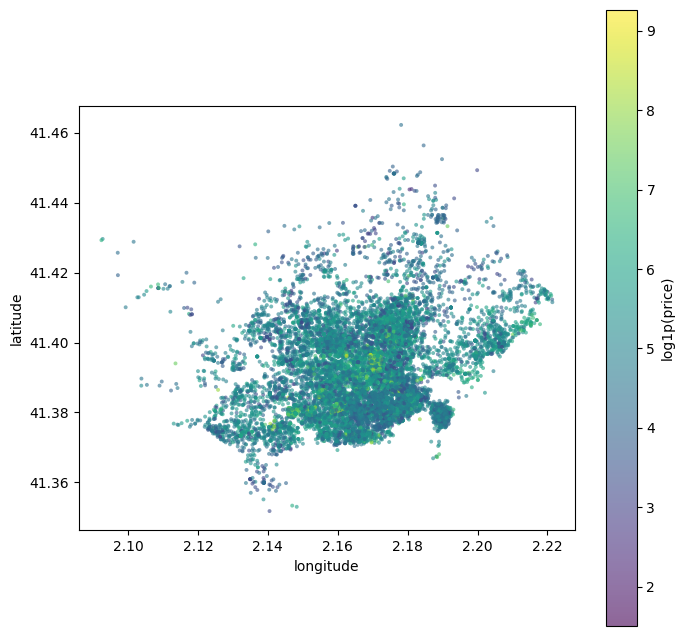

In [60]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Se ven tonos más claros (precio más alto) hacia el centro.

### 11.4 ¿Dónde están los Group Flats?

Como `bedrooms` resultó ser la variable más relacionada con `price` (secciones 9-10), tiene sentido comprobar si los anuncios grandes (los "Group Flats" de la sección 8, `bedrooms >= 10`) se concentran en alguna zona.

In [61]:
df.loc[df["bedrooms"] >= 10, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Eixample               59
Ciutat Vella           15
Sarrià-Sant Gervasi     2
Sants-Montjuïc          2
Sant Martí              1
Name: count, dtype: int64

El 75% de estos anuncios grandes (59 de 79) están en `Eixample`, lo que coincide con lo que ya insinuaban los nombres ("Great 20-Bedr... Eixample", "Fab 20-Bedrooms Group Flat in Eixample"). No es casualidad: `Eixample` tiene los edificios de ensanche con plantas grandes, aptos para convertir en pisos de varias habitaciones para grupos.

Esta sección confirma el rango de coordenadas y el patrón general de precio, y añade una pieza nueva: los anuncios extremos en `bedrooms` no están repartidos al azar, se concentran en `Eixample`. Es coherente con el resto de hallazgos de tamaño de las secciones 9 y 10.

## 12. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 15293 filas y 90 columnas originales quedan **13258 filas × 78 columnas**:
- 12 columnas 100% vacías eliminadas (`host_since`, `neighbourhood`, `instant_bookable`...).
- `bathrooms` recuperado desde `bathrooms_text` (3556 de 3565 valores).
- Reviews sin datos (`review_scores_*`, `first_review`/`last_review`) por no tener reviews todavía: `reviews_per_month` imputado a 0, el resto se deja como `NaN`/`NaT`.
- `license` convertido en flag `has_license`, y el texto imputado a `"Sin licencia"`.
- Filas sin `price` descartadas (1938).
- Columnas de bajo volumen (host/estancia, ~1.16%) descartadas.
- `bedrooms`/`beds` imputados con la mediana por `room_type`.
- `has_availability` eliminada, quedó constante tras los descartes anteriores.
- Sin duplicados de fila completa ni de `id` que eliminar: con 79 columnas, ninguna fila coincide en todo salvo `id`.
- Corregido un error de captura (`beds=127` en un piso de 4 personas).

### Variables nuevas

- `has_license`: flag booleano derivado de `license`.

### El hallazgo principal: el tamaño manda

- `bedrooms` (0.66), `accommodates` (0.65), `beds` (0.62) y `bathrooms` (0.59) son, con diferencia, las variables más correlacionadas con `price` de todo el proyecto, muy por delante de `calculated_host_listings_count` (0.21).
- Relación `bedrooms` → `price` casi monótona: 1BR ≈ 98€, 2BR ≈ 210€, 3BR ≈ 279€... hasta los "Group Flats" de 9+ dormitorios, cerca de 1800€.
- Esos Group Flats no son errores: son anuncios reales para grupos grandes, concentrados al 75% en `Eixample`, que tiene los edificios de ensanche con plantas grandes.
- `has_license` sigue importando mucho (203€ vs. 73€ de mediana), incluso dentro de un mismo `room_type`.
- Sorpresa: `review_scores_rating` no explica el precio (correlación ~0.08). Casi todo el mundo puntúa alto, así que la nota no distingue.
- `host_is_superhost` parece importar por comparación de medianas, pero la correlación real es casi nula (0.004). Conviene tener cuidado con sacar conclusiones de una sola comparación de grupos.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí (0.80-0.84): habrá que vigilar la multicolinealidad en un modelo lineal.
- `property_type` (47 categorías) necesitará agrupar las categorías raras.
- Las familias redundantes de `minimum_nights`/`maximum_nights` (8 variantes) y `availability` (5 variantes) no se han simplificado, solo diagnosticado.
- `price_quote_*` sigue sin decisión: se mantienen sin tocar, su utilidad real está por evaluar.
- Candidatas a log-transform: `price` y las variables de reviews.

## 13. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/` para su uso en los siguientes notebooks (feature engineering).

In [62]:
df.to_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_full_clean.csv", index=False)